In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import os
import sys
from pathlib import Path
sys.path.append('/lab/barcheese01/smaffa/coTISja/src')

from scripts.filter_utils import *
import re

In [116]:
# from raw sample-level data
sample_level_tis_df = pd.read_csv('/lab/barcheese01/smaffa/coTISja/data/filtered_tis_data/combined/all_samples_filtered_with_protein_seq.csv')
sample_level_tis_df = calculate_normalization_factors(sample_level_tis_df, pseudocount=1)

# grab normalization factors
experiment_table, sample_df, replicate_df = load_experiment_manifest()
tisdiff_manifest = pd.read_csv('/lab/barcheese01/smaffa/coTISja/data/ribotish_tisdiff_manifest.tsv', sep='\t')
samples = experiment_table['sample'].tolist()
codon_order = ['ATG', 'ATA', 'ATC', 'ATT', 'ACG', 'AAG', 'AGG', 'GTG', 'TTG', 'CTG']
sample_to_riboseq_total = replicate_df[replicate_df['condition'] == 'TIS'].groupby('sample')['bam_qc_file'].apply(list).apply(lambda x: np.sum([calculate_read_totals_from_bam_qc(y) for y in x]))
sample_to_riboseq_scale_factor = (sample_to_riboseq_total.median() / sample_to_riboseq_total).rename('SampleRPFScaleFactor')
sample_level_tis_df = sample_level_tis_df.merge(sample_to_riboseq_scale_factor, left_on='Sample', right_index=True)

sample_level_tis_df = sample_level_tis_df.assign(
    TIS=sample_level_tis_df.apply(lambda x: f'{x["Tid"]}_{int(x["Start"])}_{x["GenomeStart"]}:{x["GenomePos"].split(":")[-1]}', axis=1)
)

/lab/barcheese01/smaffa/miniforge3/envs/riboseq/lib/python3.11/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: divide by zero encountered in log2
  result = getattr(ufunc, method)(*inputs, **kwargs)
/lab/barcheese01/smaffa/miniforge3/envs/riboseq/lib/python3.11/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: divide by zero encountered in log2
  result = getattr(ufunc, method)(*inputs, **kwargs)
/lab/barcheese01/smaffa/miniforge3/envs/riboseq/lib/python3.11/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: divide by zero encountered in log2
  result = getattr(ufunc, method)(*inputs, **kwargs)
/lab/barcheese01/smaffa/miniforge3/envs/riboseq/lib/python3.11/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: divide by zero encountered in log2
  result = getattr(ufunc, method)(*inputs, **kwargs)
/lab/barcheese01/smaffa/miniforge3/envs/riboseq/lib/python3.11/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: divide by zero encountered in log

<Axes: xlabel='LogTranslationEfficiency', ylabel='Density'>

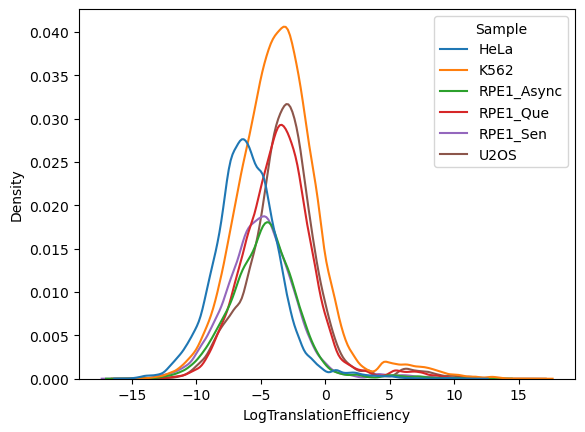

In [4]:
# calculate TE values
sample_level_tis_df = sample_level_tis_df.assign(
    LogTranslationEfficiency = lambda x: np.log2(x['SampleRPFScaleFactor'] * (x['TISCounts'] + 1)) - np.log2(x['SampleScaleFactor'] * (x['GeneRNASeqCounts'] + 1)),
    # LogTranslationEfficiency = lambda x: np.log2(x['TISCounts'] + 1) - np.log2(x['SampleScaleFactor'] * (x['GeneRNASeqCounts'] + 1)),
    TranslationEfficiency = lambda x: 2**x['LogTranslationEfficiency']
)
sample_level_tis_df = sample_level_tis_df.assign(
    TIS=sample_level_tis_df.apply(lambda x: f'{x["Tid"]}_{int(x["Start"])}_{x["GenomeStart"]}:{x["GenomePos"].split(":")[-1]}', axis=1)
)

sns.kdeplot(
    sample_level_tis_df,
    x='LogTranslationEfficiency', hue='Sample'
)

<Axes: xlabel='LogTranslationEfficiency', ylabel='Density'>

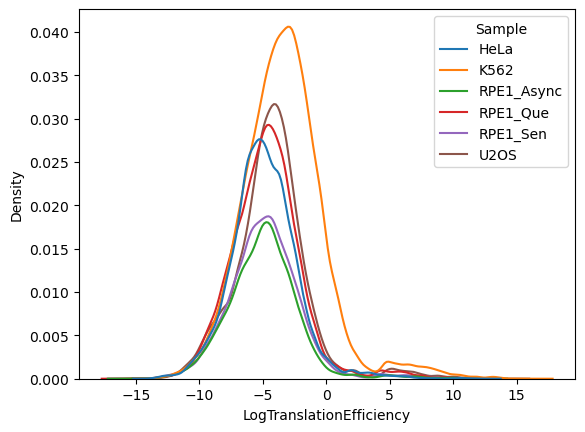

In [6]:
# calculate TE values
sample_level_tis_df = sample_level_tis_df.assign(
    # LogTranslationEfficiency = lambda x: np.log2(x['SampleRPFScaleFactor'] * (x['TISCounts'] + 1)) - np.log2(x['SampleScaleFactor'] * (x['GeneRNASeqCounts'] + 1)),
    LogTranslationEfficiency = lambda x: np.log2(x['TISCounts'] + 1) - np.log2(x['SampleScaleFactor'] * (x['GeneRNASeqCounts'] + 1)),
    TranslationEfficiency = lambda x: 2**x['LogTranslationEfficiency']
)
sample_level_tis_df = sample_level_tis_df.assign(
    TIS=sample_level_tis_df.apply(lambda x: f'{x["Tid"]}_{int(x["Start"])}_{x["GenomeStart"]}:{x["GenomePos"].split(":")[-1]}', axis=1)
)

sns.kdeplot(
    sample_level_tis_df,
    x='LogTranslationEfficiency', hue='Sample'
)

In [5]:
# from DESeq2 transformation
translation_efficiency_matrix = pd.read_csv('/lab/barcheese01/smaffa/coTISja/data/tisdiff_results/deseq2/translation_efficiency_vst_matrix.csv', index_col=0)
masked_log_te_matrix = pd.read_csv('/lab/barcheese01/smaffa/coTISja/data/tisdiff_results/deseq2/log_translation_efficiency_coeffs_masked.csv', index_col=0)

<Axes: xlabel='value', ylabel='Density'>

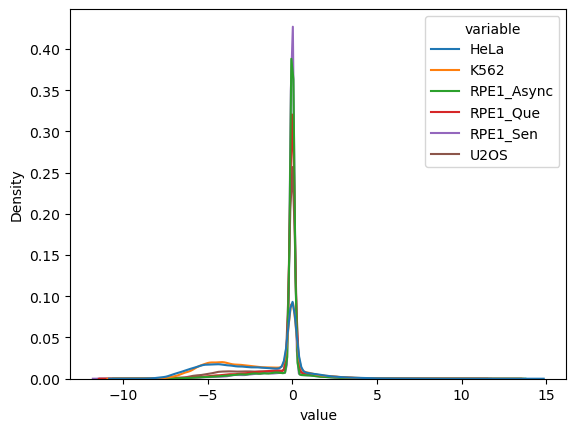

In [8]:
sns.kdeplot(
    translation_efficiency_matrix.melt(),
    x='value', hue='variable'
)

<Axes: xlabel='value', ylabel='Density'>

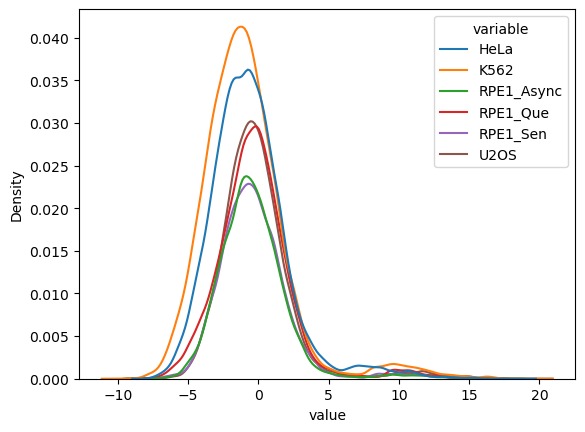

In [9]:
sns.kdeplot(
    masked_log_te_matrix.melt(),
    x='value', hue='variable'
)

<Axes: xlabel='value', ylabel='Density'>

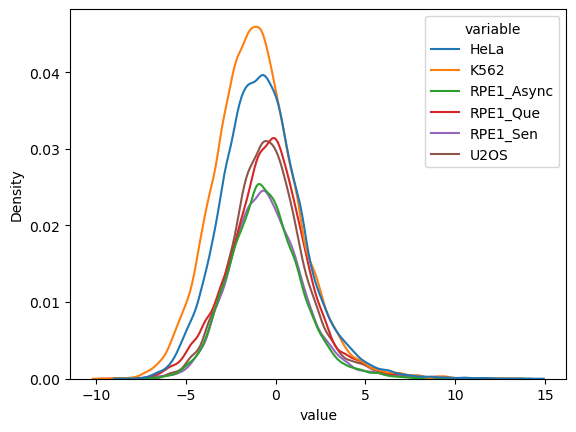

In [10]:
sns.kdeplot(
    translation_efficiency_matrix[~masked_log_te_matrix.isna()].melt(),
    x='value', hue='variable'
)

In [6]:
masked_te_matrix = translation_efficiency_matrix[~masked_log_te_matrix.isna()]

In [105]:
# sample_level_translation_efficiency = sample_level_tis_df.pivot_table(index='TIS', columns='Sample', values='TranslationEfficiency')
sample_level_riboseq_counts = sample_level_tis_df.pivot_table(index='TIS', columns='Sample', values='TISCounts')

In [462]:
sample_level_riboseq_counts = pd.read_csv('/lab/barcheese01/smaffa/coTISja/data/tisdiff_results/deseq2/rpf_summed_replicate_counts.csv', index_col=0)
sample_level_riboseq_counts_masked = pd.read_csv('/lab/barcheese01/smaffa/coTISja/data/tisdiff_results/deseq2/rpf_summed_replicate_counts_masked.csv', index_col=0)

In [117]:
tis_metadata = sample_level_tis_df[['TIS', 'IsoformID', 'Tid', 'Symbol', 'Gid', 'GeneType', 'StartCodon', 'Start', 'RecatTISType', 'MANE_Select', 'AALen', 'AASeq']].drop_duplicates()

# Summarizing differential TIS metrics

1) Need to find a way to summarize per TIS, or make a function to extract when queried, the matrix of differential comparisons between samples
    - Done: exported stacked matrices per TIS over all pairs of samples
2) Want to find a way to summarize per TIS, the "outlier-ness" of translation efficiency values in any cell line, along with a statistical measure of this quantity - maybe these are worth experimentally testing
    - Ranking heuristic is ok: reporting the variance, maximum, and minimum of TE values, along with the most significant and median differential qvalue per TIS. Outliers should have high variance and a most significant q-value which is far from the median q-value. Conversely, non-outliers but differential across samples should have high variance, and a significant median q-value (i.e. more than half of pairwise comparisons should have significant differences in translation efficiency)
3) Want to report some statistical measure per TIS, of "interesting-ness" / "different-ness" across cell lines
    - TODO: some rank which combines these?
    - TODO: ranks for each (outlier-ness, vs. differential across all pairs)?
4) Need to make some gene-level comparisons with RNA expression or protein expression or essentiality across cell lines
    - TODO: use the highest ranking "differential across all pairs" or highest variance TISs as a subset of genes to run correlations with other measurements?
    - TODO: GO enrichment analysis on the genes with the most differential TISs?
5) Add functional annotations:
    - TODO: DeepLoc2.0
    - TODO: SLiM enrichment within the differential domains
    - TODO: Presence of peptide in mass spec data

In [8]:
import os
import re

pairwise_wald_tests = dict()
for f in os.listdir('/lab/barcheese01/smaffa/coTISja/data/tisdiff_results/deseq2/pairwise_wald'):
    sample_match = re.search('(.+)_vs_(.+).csv', f)
    s1, s2 = sample_match.groups()
    pairwise_wald_tests[(s1, s2)] = pd.read_csv(f'/lab/barcheese01/smaffa/coTISja/data/tisdiff_results/deseq2/pairwise_wald/{f}', index_col=0)

In [9]:
# function to pull out statistics for a TIS across all pairwise comparisons
def extract_TIS_matrix(TIS, pairwise_dict=pairwise_wald_tests, comparison_metric='log2FoldChange', masked_tis_matrix=masked_te_matrix):
    single_samples = set()
    for s1, s2 in pairwise_dict:
        single_samples.add(s1)
        single_samples.add(s2)
    single_samples = sorted(list(single_samples))
    n_samples = len(single_samples)

    output_matrix = np.empty(shape=(n_samples, n_samples))
    output_matrix.fill(np.nan)
    output_matrix = pd.DataFrame(output_matrix, index=single_samples, columns=single_samples)

    for pair, df in pairwise_dict.items():
        s1, s2 = pair
        if TIS in df.index.tolist():
            output_matrix.loc[s1, s2] = df.loc[TIS, comparison_metric]
        if masked_tis_matrix is not None:
            if TIS in masked_tis_matrix.index.tolist() and s1 in masked_tis_matrix.columns.tolist() and s2 in masked_tis_matrix.columns.tolist():
                if np.isnan(masked_tis_matrix.loc[TIS, s1]) and np.isnan(masked_tis_matrix.loc[TIS, s2]):
                    output_matrix.loc[s1, s2] = np.nan

    return output_matrix

In [52]:
def extract_TIS_block(comparison_metric='log2FoldChange', pairwise_dict=pairwise_wald_tests, masked_tis_matrix=masked_te_matrix):
    single_samples = set()
    tis_superindex = set()
    for s1, s2 in pairwise_dict:
        single_samples.add(s1)
        single_samples.add(s2)
        tis_superindex = tis_superindex.union(pairwise_dict[(s1, s2)].index.tolist())
    single_samples = sorted(list(single_samples))
    tis_superindex = sorted(list(tis_superindex))
    n_samples = len(single_samples)
    n_tis = len(tis_superindex)

    sample_index = pd.Series(range(n_samples), index=single_samples)
    tis_index = pd.Series(range(n_tis), index=tis_superindex)

    output_matrix = np.empty(shape=(n_tis, n_samples, n_samples))
    output_matrix.fill(np.nan)

    for pair, df in tqdm(pairwise_dict.items()):
        s1, s2 = pair
        output_matrix[:, sample_index.loc[s1], sample_index.loc[s2]] = df.reindex(index=tis_superindex)[comparison_metric].values

        if masked_tis_matrix is not None:
            na_mask = masked_tis_matrix.reindex(index=tis_superindex)[[s1, s2]].isna().all(axis=1).tolist()
            output_matrix[na_mask, sample_index.loc[s1], sample_index.loc[s2]] = np.nan

    output_block = pd.DataFrame(
        output_matrix.reshape(tis_index.shape[0] * sample_index.shape[0], sample_index.shape[0]),
        index=pd.MultiIndex.from_product([tis_index.index.tolist(), sample_index.index.tolist()], names=['TIS', 'TestSample']),
        columns=sample_index.index.tolist()
    )
    output_block.columns.name='RefSample'
    return output_block

In [53]:
lfc_block = extract_TIS_block(comparison_metric='log2FoldChange')
pval_block = extract_TIS_block(comparison_metric='pvalue')
qval_block = extract_TIS_block(comparison_metric='padj')

100%|██████████| 15/15 [00:02<00:00,  5.47it/s]


In [162]:
lfc_block.to_csv('/lab/barcheese01/smaffa/coTISja/data/tisdiff_results/deseq2/lfc_matrix_stack.csv')
pval_block.to_csv('/lab/barcheese01/smaffa/coTISja/data/tisdiff_results/deseq2/pval_matrix_stack.csv')
qval_block.to_csv('/lab/barcheese01/smaffa/coTISja/data/tisdiff_results/deseq2/qval_matrix_stack.csv')

In [31]:
extract_TIS_matrix('ENST00000624697.4_245_chr1:1013998:+', masked_tis_matrix=None)

,HeLa,K562,RPE1_Async,RPE1_Que,RPE1_Sen,U2OS
HeLa,NaN,NaN,NaN,NaN,NaN,NaN
K562,-2.320435,NaN,NaN,NaN,NaN,NaN
RPE1_Async,-2.305267,0.015168,NaN,NaN,NaN,NaN
RPE1_Que,-2.827418,-0.506983,-0.522151,NaN,NaN,NaN
RPE1_Sen,-2.225019,0.095415,0.080248,0.602398,NaN,NaN
U2OS,-0.783553,1.536882,1.521714,2.043865,1.441467,NaN


In [ ]:
extract_TIS_matrix('ENST00000624697.4_245_chr1:1013998:+', masked_tis_matrix=None, comparison_metric='padj')

,HeLa,K562,RPE1_Async,RPE1_Que,RPE1_Sen,U2OS
HeLa,NaN,NaN,NaN,NaN,NaN,NaN
K562,0.006688,NaN,NaN,NaN,NaN,NaN
RPE1_Async,0.276164,1.000000,NaN,NaN,NaN,NaN
RPE1_Que,0.165688,0.940888,1.0,NaN,NaN,NaN
RPE1_Sen,0.130065,1.000000,1.0,1.000000,NaN,NaN
U2OS,0.454491,0.244651,1.0,0.882203,1.0,NaN


In [ ]:
extract_TIS_matrix('ENST00000624697.4_245_chr1:1013998:+')

,HeLa,K562,RPE1_Async,RPE1_Que,RPE1_Sen,U2OS
HeLa,NaN,NaN,NaN,NaN,NaN,NaN
K562,-2.320435,NaN,NaN,NaN,NaN,NaN
RPE1_Async,-2.305267,0.015168,NaN,NaN,NaN,NaN
RPE1_Que,-2.827418,-0.506983,NaN,NaN,NaN,NaN
RPE1_Sen,-2.225019,0.095415,NaN,NaN,NaN,NaN
U2OS,-0.783553,1.536882,1.521714,2.043865,1.441467,NaN


In [68]:
masked_te_matrix.merge(tis_metadata, left_index=True, right_on='TIS')

,HeLa,K562,RPE1_Async,RPE1_Que,RPE1_Sen,U2OS,TIS,IsoformID,Tid,Symbol,Gid,GeneType,StartCodon,Start,RecatTISType,MANE_Select
0,-1.679100,0.070726,-0.143850,0.094285,0.469473,-0.545137,ENST00000327044.7_16_chr1:959240:-,ENST00000327044.7:16,ENST00000327044.7,NOC2L,ENSG00000188976.12,protein_coding,ATG,16.0,Annotated,True
1,-0.585882,-3.504089,-1.857308,NaN,-2.346172,-1.763026,ENST00000487214.1_90_chr1:959219:-,ENST00000487214.1:90,ENST00000487214.1,NOC2L,ENSG00000188976.12,protein_coding,AAG,90.0,Other,False
3,0.084158,-1.735809,NaN,NaN,NaN,-0.657603,ENST00000624697.4_245_chr1:1013998:+,ENST00000624697.4:245,ENST00000624697.4,ISG15,ENSG00000187608.11,protein_coding,GTG,245.0,Extended,False
5,1.847290,NaN,NaN,NaN,NaN,NaN,ENST00000649529.1_50_chr1:1013546:+,ENST00000649529.1:50,ENST00000649529.1,ISG15,ENSG00000187608.11,protein_coding,GTG,50.0,Extended,True
19,-1.530954,NaN,NaN,NaN,NaN,NaN,ENST00000360001.12_263_chr1:1228793:-,ENST00000360001.12:263,ENST00000360001.12,SDF4,ENSG00000078808.21,protein_coding,ATG,263.0,Extended,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
243257,NaN,NaN,NaN,NaN,NaN,NaN,ENST00000361981.7_2862_chrX:153865190:-,ENST00000361981.7:2862,ENST00000361981.7,L1CAM,ENSG00000198910.15,protein_coding,TTG,2862.0,Truncated,False
243259,NaN,NaN,NaN,NaN,NaN,NaN,ENST00000370060.7_2986_chrX:153865190:-,ENST00000370060.7:2986,ENST00000370060.7,L1CAM,ENSG00000198910.15,protein_coding,TTG,2986.0,Truncated,True
243365,NaN,NaN,NaN,NaN,NaN,-1.989196,ENST00000475423.1_132_chrX:154764900:+,ENST00000475423.1:132,ENST00000475423.1,DKC1,ENSG00000130826.20,protein_coding,ATT,132.0,Other,False
102973,NaN,NaN,NaN,NaN,NaN,NaN,ENST00000369479.1_511_chrX:155061980:-,ENST00000369479.1:511,ENST00000369479.1,CMC4,ENSG00000182712.16,protein_coding,ATG,511.0,Truncated,False


In [473]:
# measure of uniqueness across cell lines
# 1) how many cell lines is the TIS detected in?
# 2) what is the variance in the translation efficiency across cell lines?
#   a) ranks are maybe only consistent within groups by number of cell lines
n_samples_per_tis = (~masked_te_matrix.isna()).sum(axis=1).rename('NSamples')
variance_per_tis = masked_te_matrix.var(axis=1).rename('TEVariance')
min_te_per_tis = masked_te_matrix.min(axis=1).rename('MinLogRiboOverRNA')
min_te_sample_per_tis = masked_te_matrix.dropna(how='all').idxmin(axis=1).rename('MinLogTESample')
max_te_per_tis = masked_te_matrix.max(axis=1).rename('MaxLogRiboOverRNA')
max_te_sample_per_tis = masked_te_matrix.dropna(how='all').idxmax(axis=1).rename('MaxLogTESample')

lfc_reshaped = lfc_block.melt(ignore_index=False).reset_index().pivot(index='TIS', columns=['TestSample', 'RefSample'], values='value')
qval_reshaped = qval_block.melt(ignore_index=False).reset_index().pivot(index='TIS', columns=['TestSample', 'RefSample'], values='value')
min_lfc_per_tis = lfc_reshaped.min(axis=1).rename('MinLFC')
min_lfc_pair_per_tis = lfc_reshaped.dropna(how='all').idxmin(axis=1).apply(lambda x: '/'.join(x)).rename('MinLFCSamplePair')
max_lfc_per_tis = lfc_reshaped.max(axis=1).rename('MaxLFCSamplePair')
max_lfc_pair_per_tis = lfc_reshaped.dropna(how='all').idxmax(axis=1).apply(lambda x: '/'.join(x)).rename('MaxLFCSamplePair')
min_diffq_per_tis = qval_reshaped.min(axis=1).rename('MinDiffQVal')
min_diffq_pair_per_tis = qval_reshaped.dropna(how='all').idxmin(axis=1).apply(lambda x: '/'.join(x)).rename('MinDiffQValSamplePair')
median_diffq_per_tis = qval_reshaped.median(axis=1).rename('MedianDiffQVal')
max_diffq_per_tis = qval_reshaped.max(axis=1).rename('MaxDiffQVal')
min_median_diffq_magnitude_diff_per_tis = (np.log10(min_diffq_per_tis) - np.log10(median_diffq_per_tis)).abs().rename('QValMinMedianMagnitudeDiff')
min_median_diffq_magnitude_diff_per_tis = (np.log10(min_diffq_per_tis) - np.log10(median_diffq_per_tis)).abs().rename('QValMinMedianMagnitudeDiff')

In [474]:
directions = []
for tis, min_idx in tqdm(qval_reshaped.dropna(how='all').idxmin(axis=1).items()):
    directions.append(np.sign(lfc_reshaped.loc[tis, min_idx]))
most_sig_direction_per_tis = pd.Series(directions, index=qval_reshaped.dropna(how='all').index).rename('MinDiffQValDirection')

87218it [00:13, 6649.41it/s]


In [475]:
max_riboseq_counts_per_tis = sample_level_riboseq_counts.max(axis=1).rename('MaxRiboseqCounts')
max_riboseq_rpm_per_tis = ((sample_level_riboseq_counts / sample_to_riboseq_total) * 1e6).max(axis=1).rename('MaxRiboseqRPM')
max_riboseq_sample_per_tis = ((sample_level_riboseq_counts / sample_to_riboseq_total) * 1e6).idxmax(axis=1).rename('MaxRiboseqSample')
min_riboseq_counts_per_tis = sample_level_riboseq_counts.min(axis=1).rename('MinRiboseqCounts')
min_riboseq_rpm_per_tis = ((sample_level_riboseq_counts / sample_to_riboseq_total) * 1e6).min(axis=1).rename('MinRiboseqRPM')
min_riboseq_sample_per_tis = ((sample_level_riboseq_counts / sample_to_riboseq_total) * 1e6).idxmin(axis=1).rename('MinRiboseqSample')

In [476]:
tis_stats = pd.concat([
    n_samples_per_tis, variance_per_tis,
    max_riboseq_counts_per_tis, max_riboseq_rpm_per_tis, max_riboseq_sample_per_tis, min_riboseq_counts_per_tis, min_riboseq_rpm_per_tis, min_riboseq_sample_per_tis,
    max_te_per_tis, max_te_sample_per_tis, min_te_per_tis, min_te_sample_per_tis,
    max_lfc_per_tis, max_lfc_pair_per_tis, min_lfc_per_tis, min_lfc_pair_per_tis, most_sig_direction_per_tis,
    min_diffq_per_tis, min_diffq_pair_per_tis, median_diffq_per_tis, max_diffq_per_tis, min_median_diffq_magnitude_diff_per_tis
], axis=1)
tis_summary = tis_metadata.merge(tis_stats, left_on='TIS', right_index=True)
tis_summary = tis_summary.dropna(subset=['NSamples'])

In [477]:
tis_summary.to_csv('/lab/barcheese01/smaffa/coTISja/data/tisdiff_results/deseq2/deseq2_tis_summary_statistics.csv', index=False)

In [555]:
from matplotlib.patches import Rectangle, Patch

def plot_tis_over_cell_lines(transcript_id, tis_summary_df=tis_summary, te_matrix=masked_te_matrix, 
                             figsize=(16, 3), range_extension=0.01, cds_height_scale=0.05, position_width=2.4, 
                             sample_palette='tab10', tis_type_palette='Set2'):
    df = tis_summary_df[
        tis_summary_df['Tid'].str.contains(transcript_id)
    ].sort_values('Start')[['TIS', 'Start', 'RecatTISType']].merge(
        te_matrix, left_on='TIS', right_index=True
    ).set_index(['TIS', 'Start', 'RecatTISType']).melt(ignore_index=False, var_name='Sample', value_name='LogTE').reset_index().dropna(subset=['LogTE'])
    symbol = tis_summary_df[tis_summary_df['Tid'].str.contains(transcript_id)]['Symbol'].iloc[0]

    # get key x value markers
    annotated_start = df[df['RecatTISType'] == 'Annotated']['Start'].iloc[0]
    gene_5utr_body = (0, df['Start'].max())
    xrange = gene_5utr_body[1] - gene_5utr_body[0]
    extended_xlim = (gene_5utr_body[0] - range_extension * xrange, gene_5utr_body[1] + range_extension * xrange)

    # get yrange
    ylims = (df['LogTE'].min(), df['LogTE'].max())
    yrange = ylims[1] - ylims[0]
    extended_ylim = (ylims[0] - range_extension * yrange, ylims[1] + range_extension * yrange)
    gene_cds_height = cds_height_scale * (extended_ylim[1] - extended_ylim[0])

    # set up the base plot of a transcript body ()
    fig, axs = plt.subplots(2, 1, figsize=figsize, sharex=True, height_ratios=[1, 9])
    axs[0].set_xlim(extended_xlim[0], extended_xlim[1])
    axs[1].set_xlim(extended_xlim[0], extended_xlim[1])
    axs[1].set_ylim(extended_ylim[0], extended_ylim[1])
    axs[1].axhline(0, color='black', linestyle='dashed')
    axs[0].plot([gene_5utr_body[0], gene_5utr_body[1]], [0, 0], color='black', linewidth=1, zorder=0)
    # axs[0].add_patch(Rectangle((annotated_start, -gene_cds_height/2), gene_5utr_body[1] - annotated_start, gene_cds_height, edgecolor='black', facecolor='black', fill=True, zorder=0))
    axs[0].add_patch(Rectangle((annotated_start, -gene_cds_height/2), extended_xlim[1] - annotated_start, gene_cds_height, edgecolor='black', facecolor='black', fill=True, zorder=0))

    unique_starts = sorted(df['Start'].unique().tolist())
    unique_samples = sorted(df['Sample'].unique().tolist())
    unique_tis_types = sorted(df['RecatTISType'].unique().tolist())
    sample_width = position_width / len(unique_samples)
    sample_rect_xpos = pd.Series(np.arange(-position_width/2, position_width/2, sample_width), index=unique_samples)
    start_to_tis_type = df.drop_duplicates(['Start', 'RecatTISType']).set_index('Start')['RecatTISType']

    if isinstance(sample_palette, str):
        sample_palette = pd.Series(sns.color_palette(sample_palette, n_colors=len(unique_samples)), index=unique_samples)
    elif isinstance(sample_palette, dict):
        sample_palette = pd.Series(sample_palette)
    elif not isinstance(sample_palette, pd.Series):
        raise TypeError('`sample_palette`')
    
    if isinstance(tis_type_palette, str):
        tis_type_palette = pd.Series(sns.color_palette(tis_type_palette, n_colors=len(unique_tis_types)), index=unique_tis_types)
    elif isinstance(tis_type_palette, dict):
        tis_type_palette = pd.Series(tis_type_palette)
    elif not isinstance(tis_type_palette, pd.Series):
        raise TypeError('`tis_type_palette`')

    for start in unique_starts:
        axs[1].axvline(start-position_width/2, color='black', linestyle='dotted', alpha=0.2)
        axs[1].axvline(start+position_width/2, color='black', linestyle='dotted', alpha=0.2)
        tis_type = start_to_tis_type.loc[start]
        block_width = position_width/3
        axs[0].add_patch(Rectangle((start-block_width/2, -gene_cds_height), block_width, 2*gene_cds_height, facecolor=tis_type_palette.loc[tis_type], linewidth=0, fill=True, zorder=1))

    for i, r in df.iterrows():
        start = r['Start']
        sample = r['Sample']
        height = r['LogTE']

        if height < 0:
            xy = (start + sample_rect_xpos.loc[sample], height)
            ht = -height
        else:
            xy = (start + sample_rect_xpos.loc[sample], 0)
            ht = height
        axs[1].add_patch(Rectangle(xy, sample_width, ht, edgecolor='black', facecolor=sample_palette.loc[sample], linewidth=0.1, fill=True))
    axs[1].set_xlabel('TIS position relative to transcript start')
    axs[1].set_ylabel('Log2(Ribo / RNA)')
    axs[0].set_title(f'{transcript_id} ({symbol})')
    axs[0].set_axis_off()

    axs[1].legend(
        handles = [Patch(facecolor='white', edgecolor='white', label='TIS Type')] + 
        [
            Patch(facecolor=c, edgecolor='white', label=t) for t, c in tis_type_palette.items()
        ] + [Patch(facecolor='white', edgecolor='white', label='Sample')] + [
            Patch(facecolor=c, edgecolor='white', label=s) for s, c in sample_palette.items()
        ], loc='lower left', bbox_to_anchor=(1, -0.1)
    )


In [111]:
pd.set_option('display.max_columns', None)

In [126]:
tis_summary[
    tis_summary['MANE_Select'] &
    ~tis_summary['RecatTISType'].isin(['Annotated'])
].sort_values(by=['NSamples','TEVariance'], ascending=[False, False]).head(25)

,TIS,IsoformID,Tid,Symbol,Gid,GeneType,StartCodon,Start,RecatTISType,MANE_Select,AALen,AASeq,NSamples,TEVariance,MaxRiboseqCounts,MaxRiboseqSample,MinRiboseqCounts,MinRiboseqSample,MaxTE,MaxTESample,MinTE,MinTESample,MaxLFCSamplePair,MaxLFCSamplePair,MinLFC,MinLFCSamplePair,MinDiffQVal,MinDiffQValSamplePair,MedianDiffQVal
71682,ENST00000228136.9_32_chr11:16738678:+,ENST00000228136.9:32,ENST00000228136.9,C11orf58,ENSG00000110696.11,protein_coding,GTG,32.0,uORF,True,57.0,VALLGPLADCKLLVLRLGRAARGFGIFRRDPRKDECCQRVSPAWGE...,6.0,5.266893,880.0,K562,292.0,RPE1_Que,4.243681,RPE1_Sen,-1.841560,HeLa,6.318593,RPE1_Sen/HeLa,-1.130448,U2OS/RPE1_Sen,2.763113e-51,RPE1_Sen/HeLa,0.008865
17794,ENST00000642928.2_15_chr11:33736408:-,ENST00000642928.2:15,ENST00000642928.2,CD59,ENSG00000085063.19,protein_coding,CTG,15.0,Extended,True,143.0,LEEDLGRRQVLWTITMGIQGGSVLFGLLLVLAVFCHSGHSLQCYNC...,6.0,5.199248,220.0,RPE1_Que,14.0,U2OS,8.418896,RPE1_Que,3.619717,K562,6.163860,RPE1_Que/K562,-2.041389,U2OS/RPE1_Que,7.967682e-04,RPE1_Que/K562,0.364243
77790,ENST00000539276.7_261_chr12:110281507:+,ENST00000539276.7:261,ENST00000539276.7,ATP2A2,ENSG00000174437.19,protein_coding,CTG,261.0,Extended,True,1136.0,LRAREALPSGEGREGGSGAPNPPCGARGRARGGCLGEGARGDSAPG...,6.0,4.417841,204.0,K562,22.0,RPE1_Que,-1.910423,RPE1_Async,-7.365140,HeLa,5.115780,RPE1_Async/HeLa,-0.724832,RPE1_Que/RPE1_Async,9.647069e-13,RPE1_Async/HeLa,0.473602
46023,ENST00000366553.3_8_chr1:241640361:-,ENST00000366553.3:8,ENST00000366553.3,CHML,ENSG00000203668.3,protein_coding,ATG,8.0,uORF,True,23.0,MARAGGGAPTPPSAERAASPAAS*,6.0,4.345860,42.0,K562,8.0,U2OS,1.739132,RPE1_Que,-3.335580,U2OS,5.258768,RPE1_Que/HeLa,-5.296243,U2OS/RPE1_Que,2.118812e-18,RPE1_Que/HeLa,0.000136
4545,ENST00000264255.8_55_chr2:99336278:-,ENST00000264255.8:55,ENST00000264255.8,TXNDC9,ENSG00000115514.13,protein_coding,CTG,55.0,Extended,True,250.0,LLLFHFSGVTESSAPRLNSVPFGRMEADASVDMFSKVLEHQLLQTT...,6.0,4.006037,201.0,HeLa,8.0,RPE1_Que,3.781276,HeLa,-1.958439,RPE1_Async,1.070289,U2OS/RPE1_Sen,-5.061322,RPE1_Sen/HeLa,3.846166e-07,K562/HeLa,0.819673
22060,ENST00000359591.9_358_chr14:22872097:+,ENST00000359591.9:358,ENST00000359591.9,LRP10,ENSG00000197324.10,protein_coding,TTG,358.0,uORF,True,104.0,LAKGTAPTPGLPPPPRPQPWHPEYGSSPGHGAPLGRRHQGAWAPGA...,6.0,3.773748,56.0,HeLa,56.0,HeLa,0.449743,HeLa,-4.774644,RPE1_Sen,2.304071,U2OS/RPE1_Sen,-4.965862,RPE1_Sen/HeLa,3.113412e-39,RPE1_Sen/HeLa,0.005764
16547,ENST00000359426.7_47_chr10:69318893:+,ENST00000359426.7:47,ENST00000359426.7,HK1,ENSG00000156515.26,protein_coding,CTG,47.0,Extended,True,935.0,LRRTDRPHACRPATPTASMIAAQLLAYYFTELKDDQVKKIDKYLYA...,6.0,3.733314,43.0,RPE1_Sen,10.0,HeLa,-1.067724,HeLa,-6.808130,K562,4.645296,RPE1_Sen/K562,-5.993952,K562/HeLa,7.387827e-38,K562/HeLa,0.000295
30316,ENST00000270625.7_32_chr19:49496465:+,ENST00000270625.7:32,ENST00000270625.7,RPS11,ENSG00000142534.8,protein_coding,ATT,32.0,Truncated,True,155.0,IQTERAYQKQPTIFQNKKRVLLGETGKEKLPRYYKNIGLGFKTPKE...,6.0,3.652230,483.0,HeLa,483.0,HeLa,0.943848,HeLa,-4.107292,RPE1_Que,1.421472,U2OS/RPE1_Que,-5.087532,RPE1_Que/HeLa,3.117402e-16,RPE1_Sen/HeLa,0.017930
27950,ENST00000359995.10_66_chr17:76737265:-,ENST00000359995.10:66,ENST00000359995.10,SRSF2,ENSG00000161547.18,protein_coding,GTG,66.0,Extended,True,256.0,VSPRGRQLPERRGVAPPRAEEAGASSRGSGPPLRAMSYGRPPPDVE...,6.0,3.524456,1005.0,HeLa,12.0,RPE1_Que,3.304526,HeLa,-1.959302,RPE1_Sen,1.239858,U2OS/RPE1_Sen,-5.540382,RPE1_Sen/HeLa,1.921614e-10,RPE1_Sen/HeLa,0.648192
4312,ENST00000303577.7_300_chr2:70087776:+,ENST00000303577.7:300,ENST00000303577.7,PCBP1,ENSG00000169564.7,protein_coding,GTG,300.0,Truncated,True,345.0,VTLTIRLLMHGKEVGSIIGKKGESVKRIREESGARINISEGNCPER...,6.0,3.440468,310.0,HeLa,310.0,HeLa,-0.487923,HeLa,-5.739772,RPE1_Sen,1.851235,U2OS/K562,-4.736571,K562/HeLa,8.650917e-31,K562/HeLa,0.232257


In [129]:
tis_summary[
    tis_summary['MANE_Select'] &
    ~tis_summary['RecatTISType'].isin(['Annotated'])
].sort_values(by=['NSamples','TEVariance'], ascending=[False, False]).head(25).loc[:, 'AASeq'].iloc[1]

'LEEDLGRRQVLWTITMGIQGGSVLFGLLLVLAVFCHSGHSLQCYNCPNPTADCKTAVNCSSDFDACLITKAGLQVYNKCWKFEHCNFNDVTTRLRENELTYYCCKKDLCNFNEQLENGGTSLSEKTVLLLVTPFLAAAWSLHP*'

In [ ]:
tis_summary[
    tis_summary['MANE_Select'] &
    tis_summary['RecatTISType'].isin(['Annotated'])
].sort_values(by=['NSamples','TEVariance'], ascending=[False, False]).head(25).loc[:, 'AASeq'].iloc[1]

Text(0.5, 1.0, 'CHML')

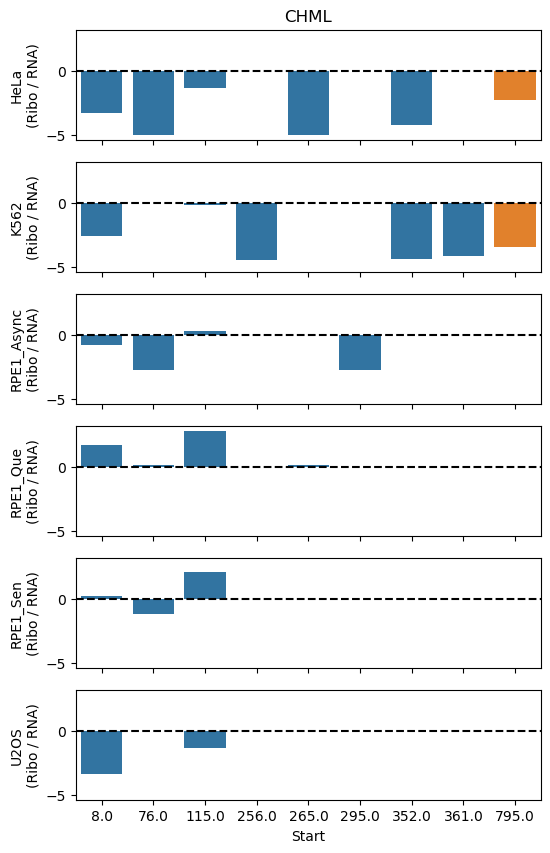

In [160]:
df = tis_summary[
    tis_summary['Tid'] == 'ENST00000366553.3'
].sort_values('Start')[['TIS', 'Start', 'RecatTISType']].merge(
    masked_te_matrix, left_on='TIS', right_index=True
).set_index(['TIS', 'Start', 'RecatTISType']).melt(ignore_index=False, var_name='Sample').reset_index()

fig, axs = plt.subplots(6, 1, figsize=(6, 10), sharex=True, sharey=True)

for i, s in enumerate(samples):
    sns.barplot(
        df[df['Sample'] == s],
        x='Start', y='value', hue='RecatTISType', ax=axs[i], legend=False
    )
    axs[i].axhline(0, linestyle='dashed', color='black')
    axs[i].set_ylabel(f'{s}\n(Ribo / RNA)')
axs[0].set_title('CHML')

Text(0.5, 1.0, 'CD59')

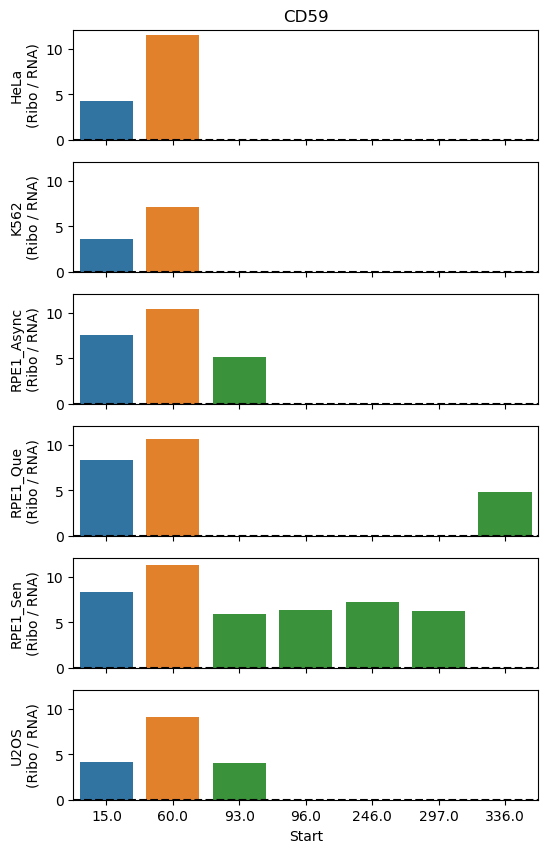

In [159]:
df = tis_summary[
    tis_summary['Tid'] == 'ENST00000642928.2'
].sort_values('Start')[['TIS', 'Start', 'RecatTISType']].merge(
    masked_te_matrix, left_on='TIS', right_index=True
).set_index(['TIS', 'Start', 'RecatTISType']).melt(ignore_index=False, var_name='Sample').reset_index()

fig, axs = plt.subplots(6, 1, figsize=(6, 10), sharex=True, sharey=True)

for i, s in enumerate(samples):
    sns.barplot(
        df[df['Sample'] == s],
        x='Start', y='value', hue='RecatTISType', ax=axs[i], legend=False
    )
    axs[i].axhline(0, linestyle='dashed', color='black')
    axs[i].set_ylabel(f'{s}\n(Ribo / RNA)')
axs[0].set_title('CD59')

Text(0.5, 1.0, 'SRSF1')

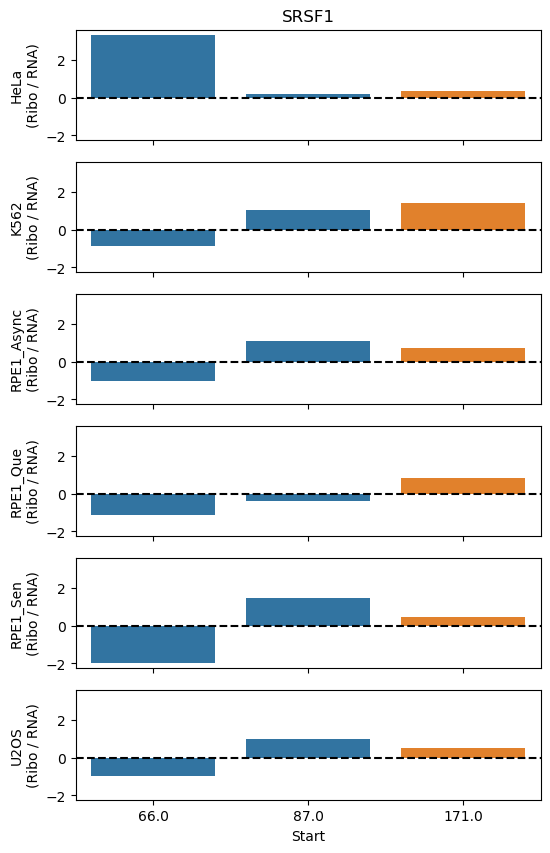

In [165]:
df = tis_summary[
    tis_summary['Tid'] == 'ENST00000359995.10'
].sort_values('Start')[['TIS', 'Start', 'RecatTISType']].merge(
    masked_te_matrix, left_on='TIS', right_index=True
).set_index(['TIS', 'Start', 'RecatTISType']).melt(ignore_index=False, var_name='Sample').reset_index()

fig, axs = plt.subplots(6, 1, figsize=(6, 10), sharex=True, sharey=True)

for i, s in enumerate(samples):
    sns.barplot(
        df[df['Sample'] == s],
        x='Start', y='value', hue='RecatTISType', ax=axs[i], legend=False
    )
    axs[i].axhline(0, linestyle='dashed', color='black')
    axs[i].set_ylabel(f'{s}\n(Ribo / RNA)')
axs[0].set_title('SRSF1')

### Check for SLiM enrichment in the differential protein sequences between canonical and non-canonical starts

In [262]:
sequence_differential_df = pair_canonical_isoforms(
    sample_level_tis_df, id_columns=['Sample', 'Tid'], canonical_columns=['Start', 'StartCodon', 'AALen', 'AASeq'], downstream_calculations=False
).drop_duplicates(subset=['Tid', 'Start'])[['TIS', 'RecatTISType', 'Start', 'CanonicalStart',  'AASeq', 'CanonicalAASeq', 'AALen', 'CanonicalAALen']]

In [264]:
differential_sequences = pd.concat([
        sequence_differential_df['TIS'],
        sequence_differential_df.apply(
            lambda x: x['AASeq'][:int(x['AALen'] - x['CanonicalAALen'])] if x['RecatTISType'] == 'Extended' else
                x['CanonicalAASeq'][:int(x['CanonicalAALen'] - x['AALen'])] if x['RecatTISType'] == 'Truncated' else
                x['AASeq'] if x['RecatTISType'] in ['uORF', 'Other'] else None,
            axis=1
        ).rename('AASeqDiffFromCanonical')
    ], axis=1)

In [ ]:
slim_classes = pd.read_csv('/lab/barcheese01/smaffa/coTISja/data/external/elm_slim_classes.tsv', sep='\t', skiprows=5)

def scan_regex_patterns(series, pattern_df=slim_classes, id_colname='ELMIdentifier'):
    pattern_presence_matrix = []
    for i, r in tqdm(pattern_df.iterrows()):
        id_name = r[id_colname]
        pattern = r['Regex']
        pattern_presence_matrix.append(series.apply(lambda x: True if re.search(pattern, x) else False).rename(id_name))
    return pd.concat(pattern_presence_matrix, axis=1)

In [268]:
slim_presence_matrix = scan_regex_patterns(differential_sequences.set_index('TIS')['AASeqDiffFromCanonical'])

353it [01:03,  5.54it/s]


In [279]:
tis_i, slim_i = np.where(slim_presence_matrix)
slim_grouper_df = pd.DataFrame({'TIS_i': tis_i, 'SLiM_i': slim_i}).merge(
    pd.DataFrame({'TIS_i': range(slim_presence_matrix.shape[0]), 'TIS': slim_presence_matrix.index})
).merge(
    pd.DataFrame({'SLiM_i': range(slim_presence_matrix.shape[1]), 'SLiM': slim_presence_matrix.columns})
).merge(
    slim_classes, left_on=['SLiM'], right_on=['ELMIdentifier']
)

In [284]:
slim_ids = slim_grouper_df.groupby('TIS')['ELMIdentifier'].apply(list)
slim_func_names = slim_grouper_df.groupby('TIS')['FunctionalSiteName'].apply(lambda x: list(set(x)))
slim_descriptions = slim_grouper_df.groupby('TIS')['Description'].apply(lambda x: list(set(x)))

In [292]:
slim_analysis_df = differential_sequences.merge(
    pd.concat([slim_ids.apply(lambda x: '|'.join(x)).rename('AASeqDiff_ELMIdentifier'), 
               slim_func_names.apply(lambda x: '|'.join(x)).rename('AASeqDiff_FunctionSiteName'), 
               slim_descriptions.apply(lambda x: '|'.join(x)).rename('AASeqDiff_Description')], axis=1),
    left_on='TIS', right_index=True
)

In [294]:
slim_analysis_df.to_csv('/lab/barcheese01/smaffa/coTISja/data/filtered_tis_data/differential_aaseq_slim_analysis.csv', index=False)

### Separate tables into (1) Continuous variation across cell lines; and (6) Outliers for each cell line

(-5.0, 15.0)

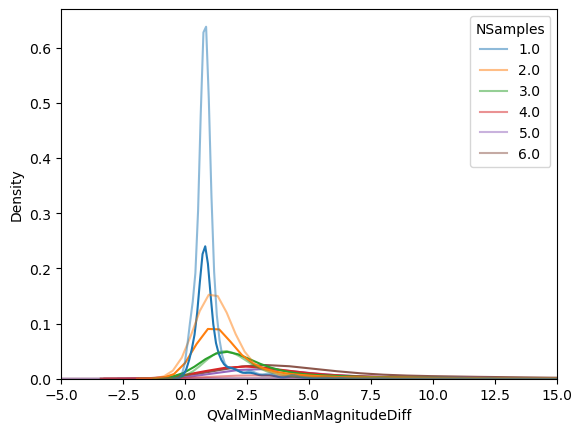

In [330]:
sns.kdeplot(
    tis_summary[tis_summary['MinDiffQVal'] < 0.01], 
    x='QValMinMedianMagnitudeDiff', hue='NSamples', palette='tab10'
)
sns.kdeplot(
    tis_summary[tis_summary['MedianDiffQVal'] < 0.01], 
    x='QValMinMedianMagnitudeDiff', hue='NSamples', palette='tab10', alpha=0.5
)
plt.xlim(-5, 15)

(-5.0, 25.0)

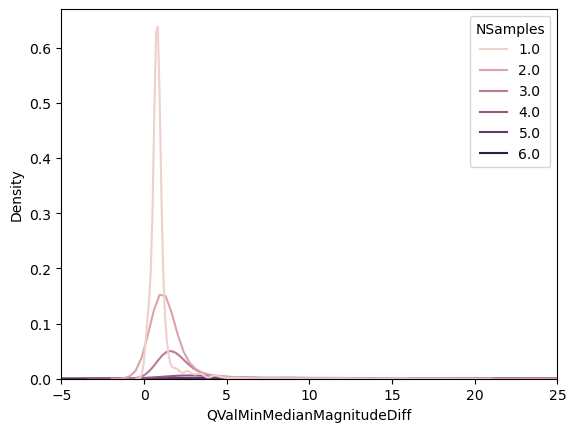

In [326]:
sns.kdeplot(
    tis_summary[tis_summary['MedianDiffQVal'] < 0.01], 
    x='QValMinMedianMagnitudeDiff', hue='NSamples'
)
plt.xlim(-5, 25)

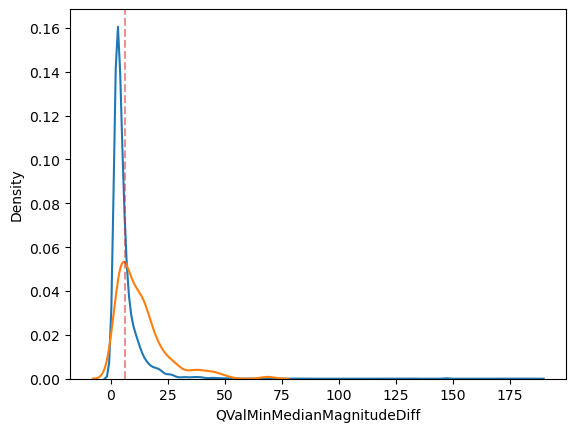

In [340]:
sns.kdeplot(
    tis_summary[(tis_summary['MinDiffQVal'] < 0.01) & (tis_summary['NSamples'] >= 5)], 
    x='QValMinMedianMagnitudeDiff',
)
sns.kdeplot(
    tis_summary[(tis_summary['MedianDiffQVal'] < 0.01) & (tis_summary['NSamples'] >= 5)], 
    x='QValMinMedianMagnitudeDiff',
)
plt.axvline(6, linestyle='dashed', color='tab:red', alpha=0.5)

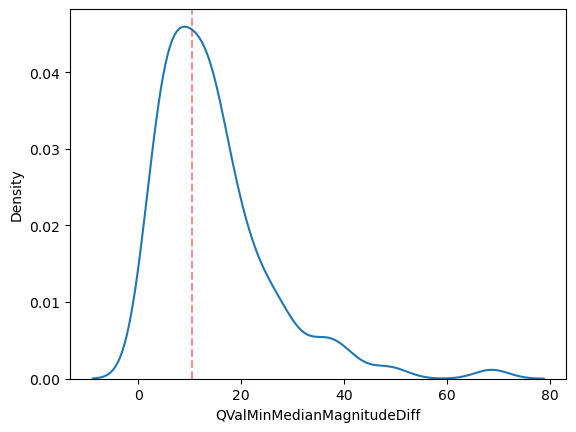

In [391]:
sns.kdeplot(
    tis_summary[(tis_summary['MedianDiffQVal'] < 0.01) & (tis_summary['NSamples'] >= 6)], 
    x='QValMinMedianMagnitudeDiff',
)
plt.axvline(
    np.quantile(tis_summary[(tis_summary['MedianDiffQVal'] < 0.01) & (tis_summary['NSamples'] >= 5)]['QValMinMedianMagnitudeDiff'], 0.5), 
    linestyle='dashed', color='tab:red', alpha=0.5
)

In [393]:
np.quantile(tis_summary[(tis_summary['MedianDiffQVal'] < 0.01) & (tis_summary['NSamples'] >= 6)]['QValMinMedianMagnitudeDiff'], 0.5)

np.float64(12.163794550701219)

In [394]:
def calculate_qval_magnitude_boundary(tis_summary, max_significance=0.01, min_samples=6):
    # sns.kdeplot(
    #     tis_summary[(tis_summary['MinDiffQVal'] < max_significance) & (tis_summary['NSamples'] >= min_samples)], 
    #     x='QValMinMedianMagnitudeDiff', label='Min Q-value < 0.01 ("Outlier" or "Continuum")'
    # )
    # outlier_x, outlier_y = plt.gca().get_lines()[-1].get_data()
    # sns.kdeplot(
    #     tis_summary[(tis_summary['MedianDiffQVal'] < max_significance) & (tis_summary['NSamples'] >= min_samples)], 
    #     x='QValMinMedianMagnitudeDiff', label='Median Q-value < 0.01 ("Continuum")'
    # )
    # trend_x, trend_y = plt.gca().get_lines()[-1].get_data()
    # midpoint_x = np.mean([trend_x[np.argmax(trend_y)], outlier_x[np.argmax(outlier_y)]])
    # plt.axvline(midpoint_x, linestyle='dashed', color='tab:red', alpha=0.5, label=f'Midpoint between modes ({midpoint_x:.2f})')
    # plt.legend()
    # plt.show()

    # return midpoint_x

    sns.kdeplot(
        tis_summary[(tis_summary['MedianDiffQVal'] < max_significance) & (tis_summary['NSamples'] >= min_samples)], 
        x='QValMinMedianMagnitudeDiff', label='Median Q-value < 0.01 ("Continuum")'
    )
    q = np.quantile(tis_summary[(tis_summary['MedianDiffQVal'] < 0.01) & (tis_summary['NSamples'] >= 5)]['QValMinMedianMagnitudeDiff'], 0.5)
    plt.axvline(q, linestyle='dashed', color='tab:red', alpha=0.5, label=f'Midpoint between modes ({q:.2f})')
    plt.legend()
    plt.show()
    return q

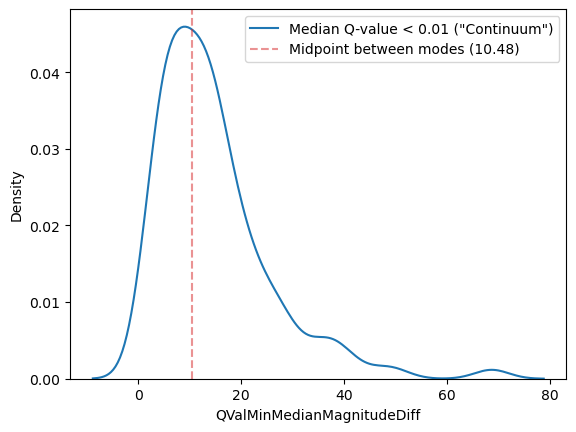

In [395]:
magnitude_boundary = calculate_qval_magnitude_boundary(tis_summary)

In [408]:
tis_summary[
    (tis_summary['QValMinMedianMagnitudeDiff'] > magnitude_boundary)# &
    # (tis_summary['MinDiffQValSamplePair'].str.contains(s))
]

,TIS,IsoformID,Tid,Symbol,Gid,GeneType,StartCodon,Start,RecatTISType,MANE_Select,AALen,AASeq,NSamples,TEVariance,MaxRiboseqCounts,MaxRiboseqRPM,MaxRiboseqSample,MinRiboseqCounts,MinRiboseqRPM,MinRiboseqSample,MaxTE,MaxTESample,MinTE,MinTESample,MaxLFCSamplePair,MaxLFCSamplePair,MinLFC,MinLFCSamplePair,MinDiffQVal,MinDiffQValSamplePair,MedianDiffQVal,MaxDiffQVal,QValMinMedianMagnitudeDiff
1,ENST00000487214.1_90_chr1:959219:-,ENST00000487214.1:90,ENST00000487214.1,NOC2L,ENSG00000188976.12,protein_coding,AAG,90.0,Other,False,247.0,KRRLAELTVDEFLASGFDSESESESENSPQAETREAREAARSPDKP...,5.0,1.114432,54.0,1.033935,HeLa,54.0,1.033935,HeLa,-0.585882,HeLa,-3.504089,K562,3.911677,U2OS/RPE1_Que,-5.041559,RPE1_Que/HeLa,2.151207e-13,K562/HeLa,0.061848,1.00000,11.458646
40,ENST00000488042.6_39_chr1:1324590:-,ENST00000488042.6:39,ENST00000488042.6,INTS11,ENSG00000127054.23,protein_coding,ACG,39.0,Other,False,277.0,TPLGAGQDVGRSCILVSIAGKNVMLDCGMHMGFNDDRRFPDFSYIT...,5.0,3.547189,37.0,0.840946,RPE1_Async,17.0,0.708437,HeLa,-0.299866,HeLa,-4.781816,K562,4.300961,RPE1_Async/K562,-5.890639,RPE1_Que/HeLa,2.845612e-19,K562/HeLa,0.021854,1.00000,16.885358
65,ENST00000291386.4_306_chr1:1574557:-,ENST00000291386.4:306,ENST00000291386.4,SSU72,ENSG00000160075.13,protein_coding,ATG,306.0,Annotated,True,194.0,MPSSPLRVAVVCSSNQNRSMEAHNILSKRGFSVRSFGTGTHVKLPG...,6.0,2.582603,154.0,2.948630,HeLa,12.0,1.123297,RPE1_Que,1.328189,HeLa,-3.123195,RPE1_Sen,1.867186,U2OS/RPE1_Sen,-4.740931,RPE1_Sen/HeLa,1.469106e-24,K562/HeLa,0.071759,1.00000,22.688824
66,ENST00000378725.3_30_chr1:1574557:-,ENST00000378725.3:30,ENST00000378725.3,SSU72,ENSG00000160075.13,protein_coding,ATG,30.0,Other,False,162.0,MPSSPLRVAVVCSSNQNRSMEAHNILSKRGFSVRSFGTGTHVKLPG...,6.0,2.582603,154.0,2.948630,HeLa,12.0,1.123297,RPE1_Que,1.328189,HeLa,-3.123195,RPE1_Sen,1.867186,U2OS/RPE1_Sen,-4.740931,RPE1_Sen/HeLa,1.469106e-24,K562/HeLa,0.071759,1.00000,22.688824
250,ENST00000377038.8_113_chr1:10472416:-,ENST00000377038.8:113,ENST00000377038.8,DFFA,ENSG00000160049.13,protein_coding,ATC,113.0,Truncated,True,317.0,IRTLKPCLLRRNYSREQHGVAASCLEDLRSKACDILAIDKSLTPVT...,4.0,1.217142,58.0,1.624298,K562,5.0,0.188079,RPE1_Sen,0.340373,HeLa,-1.926620,K562,1.810682,RPE1_Sen/RPE1_Que,-4.106870,RPE1_Que/HeLa,4.004175e-13,K562/HeLa,0.681763,1.00000,12.231121
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
247217,ENST00000550657.1_59_chr12:93441884:-,ENST00000550657.1:59,ENST00000550657.1,UBE2N,ENSG00000177889.11,protein_coding,ATG,59.0,Annotated,False,152.0,MAGLPRRIIKETQRLLAEPVPGIKAEPDESNARYFHVVIAGPQDSP...,4.0,2.357901,396.0,14.618678,K562,0.0,0.000000,U2OS,5.214190,HeLa,1.760358,RPE1_Que,2.527201,RPE1_Sen/RPE1_Que,-3.434159,RPE1_Que/HeLa,5.558386e-29,K562/HeLa,0.617075,1.00000,28.045389
247417,ENST00000553300.6_207_chr14:21234193:-,ENST00000553300.6:207,ENST00000553300.6,HNRNPC,ENSG00000092199.20,protein_coding,ATG,207.0,Annotated,True,293.0,MASNVTNKTDPRSMNSRVFIGNLNTLVVKKSDVEAIFSKYGKIVGC...,4.0,1.862618,1832.0,67.629843,K562,0.0,0.000000,U2OS,4.023583,HeLa,0.858539,RPE1_Que,3.542166,RPE1_Sen/RPE1_Que,-3.993084,RPE1_Que/RPE1_Async,5.139386e-21,RPE1_Que/HeLa,0.361541,0.94066,19.847247
247419,ENST00000556309.5_19_chr14:21383927:-,ENST00000556309.5:19,ENST00000556309.5,SUPT16H,ENSG00000092201.11,protein_coding,ATG,19.0,Annotated,False,66.0,MAVTLDKDAYYRRVKRLYSNWRKGEDEYANVDAIVVSVGVDEEIVY...,6.0,2.243109,94.0,3.470090,K562,0.0,0.000000,U2OS,0.585365,HeLa,-3.366698,RPE1_Async,1.236362,RPE1_Que/RPE1_Async,-4.094579,RPE1_Async/HeLa,4.743739e-17,K562/HeLa,0.106034,1.00000,15.349325
247422,ENST00000535847.1_63_chr14:22589157:-,ENST00000535847.1:63,ENST00000535847.1,DAD1,ENSG00000129562.12,protein_coding,ATG,63.0,Annotated,False,65.0,MSASVVSVISRFLEEYLSSTPQRLKLLDAYLLYILLTGALHLPENT...,3.0,3.690629,56.0,3.369890,RPE1_Que,0.0,0.000000,U2OS,2.362890,HeLa,-1.060508,K562,6.765685,U2OS/K562,-5.708324,RPE1_Que/RPE1_Async,6.088653e-31,K562/HeLa,0.041162,0.90860,2

In [539]:
qval_magnitude_diff = 5
outlier_df = []
for s in samples:
    if s == 'HeLa':
        outlier_subset = tis_summary[
            ((tis_summary['QValMinMedianMagnitudeDiff'] > qval_magnitude_diff) & # requirement for outlier
             ((tis_summary['MinDiffQValDirection'] < 0) & # first cell line is a negative outlier or second cell line is a positive outlier
              ((tis_summary['MinDiffQValSamplePair'].str.startswith(s) & (tis_summary['MinLogTESample'] == s)) | 
               (tis_summary['MinDiffQValSamplePair'].str.endswith(s) & (tis_summary['MaxLogTESample'] == s))) |
              ((tis_summary['MinDiffQValDirection'] > 0) & # first cell line is a positive outlier or second cell line is a negative outlier
               (tis_summary['MinDiffQValSamplePair'].str.startswith(s) & (tis_summary['MaxLogTESample'] == s)) |
               (tis_summary['MinDiffQValSamplePair'].str.endswith(s) & (tis_summary['MinLogTESample'] == s))))) |
            (tis_summary['NSamples'] == 1) & (tis_summary['MaxDiffQVal'] < 0.01) & (tis_summary['MaxRiboseqSample'] == s)
        ]
        outlier_subset = outlier_subset.assign(LikelyOutlier=s)
    else:
        outlier_subset = tis_summary[
            ((tis_summary['QValMinMedianMagnitudeDiff'] > qval_magnitude_diff) & # requirement for outlier
             ((tis_summary['MinDiffQValDirection'] < 0) & # first cell line is a negative outlier or second cell line is a positive outlier
              ((tis_summary['MinDiffQValSamplePair'].str.startswith(s) & (tis_summary['MinLogTESample'] == s)) | 
               (tis_summary['MinDiffQValSamplePair'].str.endswith(s) & (tis_summary['MaxLogTESample'] == s))) |
              ((tis_summary['MinDiffQValDirection'] > 0) & # first cell line is a positive outlier or second cell line is a negative outlier
               (tis_summary['MinDiffQValSamplePair'].str.startswith(s) & (tis_summary['MaxLogTESample'] == s)) |
               (tis_summary['MinDiffQValSamplePair'].str.endswith(s) & (tis_summary['MinLogTESample'] == s)))) &
             (~tis_summary['MinDiffQValSamplePair'].str.contains('HeLa'))) |
            (tis_summary['NSamples'] == 1) & (tis_summary['MaxDiffQVal'] < 0.01) & (tis_summary['MaxRiboseqSample'] == s)
        ]
        outlier_subset = outlier_subset.assign(LikelyOutlier=s)
    print(s, len(outlier_subset))
    outlier_df.append(outlier_subset)
outlier_df = pd.concat(outlier_df, axis=0)
outlier_df = outlier_df[~(outlier_df['RecatTISType'].isin(['Annotated']))]

HeLa 6885
K562 445
RPE1_Async 227
RPE1_Que 651
RPE1_Sen 189
U2OS 126


In [542]:
func_annotated_outlier_df = outlier_df.merge(slim_analysis_df, how='left')
func_annotated_outlier_df = func_annotated_outlier_df.sort_values(by=['NSamples', 'TEVariance'], ascending=[False, False])

In [543]:
func_annotated_outlier_df.to_csv('/lab/barcheese01/smaffa/coTISja/data/tisdiff_results/deseq2/alternative_translation_efficiency_outliers.csv')

In [544]:
continuum_df = tis_summary[
    (tis_summary['QValMinMedianMagnitudeDiff'] < qval_magnitude_diff) &
    (tis_summary['MedianDiffQVal'] < 0.01) & 
    (tis_summary['NSamples'] >= 3) &
    ~(tis_summary['RecatTISType'].isin(['Annotated']))
]

In [545]:
func_annotated_continuum_df = continuum_df.merge(slim_analysis_df, how='left')
func_annotated_continuum_df = func_annotated_continuum_df.sort_values(by=['NSamples', 'TEVariance'], ascending=[False, False])

In [546]:
func_annotated_continuum_df.to_csv('/lab/barcheese01/smaffa/coTISja/data/tisdiff_results/deseq2/alternative_translation_efficiency_continuous.csv')

In [552]:
func_annotated_outlier_df[
    func_annotated_outlier_df['MANE_Select']
]

,TIS,IsoformID,Tid,Symbol,Gid,GeneType,StartCodon,Start,RecatTISType,MANE_Select,AALen,AASeq,NSamples,TEVariance,MaxRiboseqCounts,MaxRiboseqRPM,MaxRiboseqSample,MinRiboseqCounts,MinRiboseqRPM,MinRiboseqSample,MaxLogRiboOverRNA,MaxLogTESample,MinLogRiboOverRNA,MinLogTESample,MaxLFCSamplePair,MaxLFCSamplePair,MinLFC,MinLFCSamplePair,MinDiffQValDirection,MinDiffQVal,MinDiffQValSamplePair,MedianDiffQVal,MaxDiffQVal,QValMinMedianMagnitudeDiff,LikelyOutlier,AASeqDiffFromCanonical,AASeqDiff_ELMIdentifier,AASeqDiff_FunctionSiteName,AASeqDiff_Description
2342,ENST00000228136.9_32_chr11:16738678:+,ENST00000228136.9:32,ENST00000228136.9,C11orf58,ENSG00000110696.11,protein_coding,GTG,32.0,uORF,True,57.0,VALLGPLADCKLLVLRLGRAARGFGIFRRDPRKDECCQRVSPAWGE...,6,5.266893,904,44.718522,RPE1_Async,31,0.593555,HeLa,4.243681,RPE1_Sen,-1.841560,HeLa,6.318593,RPE1_Sen/HeLa,-1.130448,U2OS/RPE1_Sen,1.0,2.763113e-51,RPE1_Sen/HeLa,0.008865,1.000000,48.506281,HeLa,VALLGPLADCKLLVLRLGRAARGFGIFRRDPRKDECCQRVSPAWGE...,CLV_NRD_NRD_1|CLV_PCSK_KEX2_1|DOC_CYCLIN_RevRx...,Glycosaminoglycan attachment site|di Arginine ...,Glycosaminoglycan attachment site|Apicomplexa ...
2544,ENST00000539276.7_261_chr12:110281507:+,ENST00000539276.7:261,ENST00000539276.7,ATP2A2,ENSG00000174437.19,protein_coding,CTG,261.0,Extended,True,1136.0,LRAREALPSGEGREGGSGAPNPPCGARGRARGGCLGEGARGDSAPG...,6,4.417841,204,7.530834,K562,6,0.114882,HeLa,-1.910423,RPE1_Async,-7.365140,HeLa,5.115780,RPE1_Async/HeLa,-0.724832,RPE1_Que/RPE1_Async,1.0,9.647069e-13,RPE1_Async/HeLa,0.473602,1.000000,11.691019,HeLa,LRAREALPSGEGREGGSGAPNPPCGARGRARGGCLGEGARGDSAPG...,CLV_PCSK_SKI1_1|DEG_Nend_Nbox_1|DOC_PP2A_B56_1...,Glycosaminoglycan attachment site|FHA phosphop...,Casein kinase 2 (CK2) phosphorylation site|Pho...
221,ENST00000264255.8_55_chr2:99336278:-,ENST00000264255.8:55,ENST00000264255.8,TXNDC9,ENSG00000115514.13,protein_coding,CTG,55.0,Extended,True,250.0,LLLFHFSGVTESSAPRLNSVPFGRMEADASVDMFSKVLEHQLLQTT...,6,4.006037,560,10.722292,HeLa,8,0.338541,RPE1_Sen,3.781276,HeLa,-1.958439,RPE1_Async,1.070289,U2OS/RPE1_Sen,-5.061322,RPE1_Sen/HeLa,-1.0,3.846166e-07,K562/HeLa,0.819673,1.000000,6.328613,HeLa,LLLFHFSGVTESSAPRLNSVPFGR,DEG_Nend_Nbox_1|LIG_14-3-3_CanoR_1|LIG_BRCT_BR...,14-3-3 binding phosphopeptide motif|Glycosamin...,Glycosaminoglycan attachment site|N-terminal m...
960,ENST00000359591.9_358_chr14:22872097:+,ENST00000359591.9:358,ENST00000359591.9,LRP10,ENSG00000197324.10,protein_coding,TTG,358.0,uORF,True,104.0,LAKGTAPTPGLPPPPRPQPWHPEYGSSPGHGAPLGRRHQGAWAPGA...,6,3.773748,167,3.197541,HeLa,8,0.494674,RPE1_Async,0.449743,HeLa,-4.774644,RPE1_Sen,2.304071,U2OS/RPE1_Sen,-4.965862,RPE1_Sen/HeLa,-1.0,3.113412e-39,RPE1_Sen/HeLa,0.005764,1.000000,36.267501,HeLa,LAKGTAPTPGLPPPPRPQPWHPEYGSSPGHGAPLGRRHQGAWAPGA...,CLV_NRD_NRD_1|CLV_PCSK_KEX2_1|DEG_Kelch_KLHL12...,Casein kinase 2 (CK2) Phosphorylation site|SPO...,This is the motif recognized by class II SH3 d...
705,ENST00000359426.7_47_chr10:69318893:+,ENST00000359426.7:47,ENST00000359426.7,HK1,ENSG00000156515.26,protein_coding,CTG,47.0,Extended,True,935.0,LRRTDRPHACRPATPTASMIAAQLLAYYFTELKDDQVKKIDKYLYA...,6,3.733314,72,3.363783,RPE1_Async,18,0.593555,HeLa,-1.067724,HeLa,-6.808130,K562,4.645296,RPE1_Sen/K562,-5.993952,K562/HeLa,-1.0,7.387827e-38,K562/HeLa,0.000295,1.000000,33.601921,HeLa,LRRTDRPHACRPATPTAS,CLV_NRD_NRD_1|CLV_PCSK_KEX2_1|CLV_PCSK_SKI1_1|...,di Arginine retention/retrieving signal|NRD cl...,The di-Arg ER retention motif is defined by tw...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4688,ENST00000530997.7_62_chr14:50831100:-,ENST00000530997.7:62,ENST00000530997.7,NIN,ENSG00000100503.28,protein_coding,CTG,62.0,uORF,True,50.0,LGAAVPLPPPSPECASGHGSRGGAGRLSPGTQALEAGCRLCGRSGE...,1,NaN,22,2.015457,U2OS,0,0.000000,HeLa,-4.208872,U2OS,-4.208872,U2OS,-6.656130,U2OS/HeLa,-9.567251,U2OS/RPE1_Que,-1.0,1.888394e-04,U2OS/RPE1_Que,0.000772,0.005110,0.611247,U2O

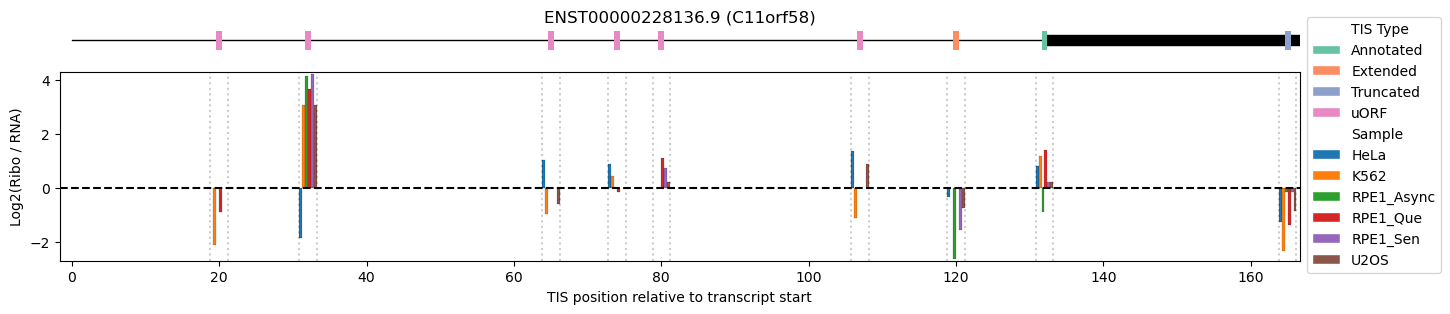

In [551]:
plot_tis_over_cell_lines('ENST00000228136.9')

In [553]:
func_annotated_continuum_df[
    func_annotated_continuum_df['MANE_Select']
]

,TIS,IsoformID,Tid,Symbol,Gid,GeneType,StartCodon,Start,RecatTISType,MANE_Select,AALen,AASeq,NSamples,TEVariance,MaxRiboseqCounts,MaxRiboseqRPM,MaxRiboseqSample,MinRiboseqCounts,MinRiboseqRPM,MinRiboseqSample,MaxLogRiboOverRNA,MaxLogTESample,MinLogRiboOverRNA,MinLogTESample,MaxLFCSamplePair,MaxLFCSamplePair,MinLFC,MinLFCSamplePair,MinDiffQValDirection,MinDiffQVal,MinDiffQValSamplePair,MedianDiffQVal,MaxDiffQVal,QValMinMedianMagnitudeDiff,AASeqDiffFromCanonical,AASeqDiff_ELMIdentifier,AASeqDiff_FunctionSiteName,AASeqDiff_Description
252,ENST00000281382.11_21_chr2:46617020:-,ENST00000281382.11:21,ENST00000281382.11,PIGF,ENSG00000151665.14,protein_coding,ATG,21.0,uORF,True,16.0,MVGGSSSPLPFRGRES*,6,1.454459,108,4.305970,RPE1_Que,18,1.038815,RPE1_Async,3.590561,RPE1_Que,0.578817,RPE1_Async,2.525148,RPE1_Que/RPE1_Async,-2.241018,RPE1_Async/HeLa,-1.0,2.616869e-04,RPE1_Async/HeLa,0.006139,1.000000,1.370347,MVGGSSSPLPFRGRES*,DOC_WW_Pin1_4|MOD_ProDKin_1|TRG_ER_diArg_1,MAPK Phosphorylation Site|di Arginine retentio...,The di-Arg ER retention motif is defined by tw...
1084,ENST00000316097.13_16_chr19:1905414:+,ENST00000316097.13:16,ENST00000316097.13,SCAMP4,ENSG00000227500.12,protein_coding,CTG,16.0,Extended,True,251.0,LRSRPDPSGGCRLQPALVGETEMSEKENNFPPLPKFIPVKPCFYQN...,6,1.340770,128,7.863076,RPE1_Que,15,0.287204,HeLa,2.074143,RPE1_Async,-0.813790,HeLa,2.900647,RPE1_Async/HeLa,-0.884977,U2OS/RPE1_Async,1.0,3.323599e-07,RPE1_Async/HeLa,0.009316,1.000000,4.447618,LRSRPDPSGGCRLQPALVGETE,DEG_Nend_Nbox_1|DOC_USP7_MATH_1|MOD_GlcNHglyca...,Glycosaminoglycan attachment site|USP7 binding...,Glycosaminoglycan attachment site|The di-Arg E...
99,ENST00000269576.6_1806_chr17:40818453:-,ENST00000269576.6:1806,ENST00000269576.6,KRT10,ENSG00000186395.9,protein_coding,ATT,1806.0,Other,True,25.0,IIEEVAPDGRVLSSMVESETKKHYY*,6,1.307116,408,15.061668,K562,52,1.799813,HeLa,2.976050,RPE1_Sen,0.336084,HeLa,2.790020,RPE1_Sen/HeLa,-1.071698,U2OS/RPE1_Sen,1.0,2.553932e-07,RPE1_Sen/HeLa,0.007810,1.000000,4.485440,IIEEVAPDGRVLSSMVESETKKHYY*,DEG_Nend_Nbox_1|LIG_14-3-3_CanoR_1|MOD_CK2_1|M...,14-3-3 binding phosphopeptide motif|Casein kin...,Casein kinase 2 (CK2) phosphorylation site|N-t...
1011,ENST00000225792.10_41_chr17:64506248:-,ENST00000225792.10:41,ENST00000225792.10,DDX5,ENSG00000108654.17,protein_coding,CTG,41.0,Extended,True,657.0,LVSSVSFLRCRPRKASPSSRPFPATCRTLFYILRSPPTATIDAMSG...,6,1.170324,380,14.028024,K562,13,1.216905,RPE1_Que,-1.178925,K562,-4.011155,RPE1_Que,0.955436,RPE1_Sen/RPE1_Que,-2.879558,RPE1_Que/K562,-1.0,1.084835e-07,RPE1_Async/K562,0.007691,1.000000,4.850616,LVSSVSFLRCRPRKASPSSRPFPATCRTLFYILRSPPTATIDA,CLV_NRD_NRD_1|CLV_PCSK_SKI1_1|DEG_Nend_Nbox_1|...,di Arginine retention/retrieving signal|FHA ph...,The di-Arg ER retention motif is defined by tw...
98,ENST00000269576.6_1593_chr17:40818970:-,ENST00000269576.6:1593,ENST00000269576.6,KRT10,ENSG00000186395.9,protein_coding,ACG,1593.0,Other,True,96.0,TAAVPAAATVVAVPAAAAAATGAAAPAAAAAPAADTAAAAPAEATS...,6,0.785110,566,20.894373,K562,56,2.948630,HeLa,3.036076,U2OS,1.049251,K562,2.090751,U2OS/K562,-0.048419,K562/HeLa,1.0,3.797299e-06,U2OS/K562,0.009388,1.000000,3.393077,TAAVPAAATVVAVPAAAAAATGAAAPAAAAAPAADTAAAAPAEATS...,CLV_PCSK_SKI1_1|DOC_PP2A_B56_1|DOC_USP7_MATH_1...,14-3-3 binding phosphopeptide motif|FHA phosph...,Casein kinase 2 (CK2) phosphorylation site|Pho...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1340,ENST00000545606.6_345_chr12:67269702:+,ENST00000545606.6:345,ENST00000545606.6,CAND1,ENSG00000111530.14,protein_coding,ATC,345.0,Extended,True,1235.0,IEAVNMASASYHISNLLEKMTSSDKDFRFMATNDLMTELQKDSIKL...,3,0.007198,18,0.890413,RPE1_Async,0,0.000000,HeLa,-3.363605,RPE1_Async,-3.520479,RPE1_Que,9.472455,U2OS/RPE1_Que,-7.720388,RPE1_Que/K562,1.0,3.105436e-04,U2OS/RPE1_Que,0.008493,1.000000,1.436939,IEAVN,DEG_CRBN_cyclicCter_1|DEG_Nend_Nbox_1,N-degron|C-terminal cyclic imide degron motif ...,Degr

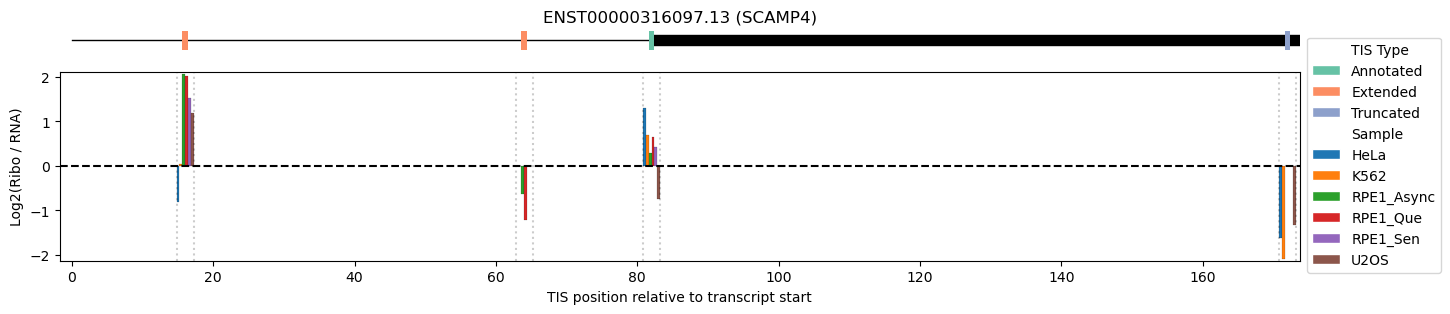

In [557]:
plot_tis_over_cell_lines('ENST00000316097.13')

## perform analysis again, pre-blocking the conditions to test

In [296]:
cell_line_samples = ['HeLa', 'K562', 'RPE1_Async', 'U2OS']
rpe_condition_samples = ['RPE1_Async', 'RPE1_Que', 'RPE1_Sen']

In [311]:
lfc_block.loc[pd.IndexSlice[:, cell_line_samples], cell_line_samples]

RefSample                                              HeLa      K562  \
TIS                                    TestSample                       
ENST00000000233.10_88_chr7:127588498:+ HeLa             NaN       NaN   
                                       K562        0.379221       NaN   
                                       RPE1_Async  1.769063  1.389841   
                                       U2OS        0.987067  0.607846   
ENST00000000412.8_116_chr12:8949529:-  HeLa             NaN       NaN   
...                                                     ...       ...   
ENST00000850956.1_255_chr11:65499299:+ U2OS       -3.175562 -4.662556   
ENST00000850956.1_270_chr11:65499314:+ HeLa             NaN       NaN   
                                       K562        0.769523       NaN   
                                       RPE1_Async -5.524304 -6.293827   
                                       U2OS       -4.597810 -5.367333   

RefSample                                          RPE1_Async  U2OS  
TIS                                    TestSample                    
ENST00000000233.10_88_chr7:127588498:+ HeLa               NaN   NaN  
                                       K562               NaN   NaN  
                                       RPE1_Async         NaN   NaN  
                                       U2OS         -0.781996   NaN  
ENST00000000412.8_116_chr12:8949529:-  HeLa               NaN   NaN  
...                                                       ...   ...  
ENST00000850956.1_255_chr11:65499299:+ U2OS               NaN   NaN  
ENST00000850956.1_270_chr11:65499314:+ HeLa               NaN   NaN  
                                       K562               NaN   NaN  
                                       RPE1_Async         NaN   NaN  
                                       U2OS               NaN   NaN  

[679352 rows x 4 columns]